# **Exploración de sesgos en word embeddings**

### basado en el workshop https://learn.responsibly.ai/word-embedding

y en la [adaptación de Lucía González al castellano](https://colab.research.google.com/drive/1mpnZnvrE4ks9TOMu85W6wJRplDPpeLCL).

Esta es una adaptación de lo provisto en el workshop (y su respectiva notebook) sobre el toolkit [`responsibly`](https://docs.responsibly.ai/) - para auditar y mitigar sesgo, con el objetivo de generar sistemas de aprendizaje automático más equitativos.

## Resumen

En este tutorial vamos a explorar **sesgos** en **word embeddings** - una pieza clave en muchos modelos de aprendizaje automático que trabajan sobre lenguaje humano.


Un word embedding es un espacio vectorial donde las palabras son representadas como **vectores** de numeros reales con **n dimensiones**. En este espacio las palabras que se utilizan de manera similar en el lenguaje están cerca unas de otras. Siguiendo lo que se conoce como **Hipótesis distribucional** (Harris 1954), el comportamiento y contexto (entendido como contexto _inmediato_, es decir n palabras antes y n palabras después) de las palabras en los textos es utilizado para comprender su **significado**.

Las coordenadas de los vectores en este espacio son aprendidas por una red neuronal procesando cantidades enormes de texto como noticias, articulos de wikipedia, posts de reddit, etc. Si bien esta red neuronal toma como entrada texto, perfectamente entendible para los humanos, el resultado no es interpretable. Los vectores generados no reflejan significados que puedan ser comprendidos utilizando conocimiento general o sentido común.

A pesar de esto, los word embeddings tienen una representación **geométrica** que nos va a permitir construir una noción intuitiva sobre los posibles sesgos y estereotipos contenidos en los mismos.

El sesgo puede afectar cualquier aspecto de nuestra forma de ver el mundo. Para poder ilustrar este fenómeno trabajaremos sobre sesgo de **género**. Utilizaremos una representación sobresimplificada del género entendiendolo como binario. Esta simplificación tiene como objetivo facilitar el entendimiento de las técnicas a desarrollar pero deberían ser adaptadas para su uso en aplicaciones reales.

### ¿Qué vamos a hacer en el tutorial?

1. **Definir**. Ya decidimos que vamos a trabajar sobre sesgo de género, pero incluso simplificando la definición de género, este sigue siendo un fenómeno complejo. Primero que nada vamos a **acotar** nuestra definición. Vamos a dedicarnos particularmente a sesgos y estereotipos relacionados a **profesiones**.

2. **Diagnosticar**. Vamos a diagnosticar si nuestro embedding está sesgado respecto a nuestra definición de sesgo basada en profesiones. Para esto, tenemos que construir una definicion de sesgo respecto a nuestro objeto de estudio. ¿Qué característica del word embedding nos hace notar que contiene sesgo?

### Descargos

En este ejemplo nos enfocamos en sesgo de género simplificándolo a un fenómeno binario, pero entendemos que se trata de una sobresimplificación, una primera aproximación que requiere de una mayor complejidad para tratar los fenómenos de sesgo como construcciones sociales.

Este material es un ejercicio puntual, no una perspectiva completa sobre sesgo en aprendizaje automático, equidad o inteligencia artificial responsable.

# Parte 0: Instalación de dependencias

In [2]:
# Instalamos las librerías necesarias
!pip install gensim numpy scipy scikit-learn matplotlib seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 32.1 MB/s eta 0:00:00


## Validar la instalación de `gensim`


In [3]:
import gensim
import numpy as np
import scipy
import sklearn
import matplotlib

print('gensim:', gensim.__version__)
print('numpy:', np.__version__)
print('matplotlib:', matplotlib.__version__)

gensim: 4.4.0
numpy: 2.0.2
matplotlib: 3.10.0


In [4]:
import warnings
warnings.filterwarnings('ignore')

---

**Nota:** Esta versión actualizada reemplaza la librería `responsibly` (que ya no es compatible con versiones actuales de Python y sus dependencias) por implementaciones propias equivalentes usando `gensim`, `numpy`, `matplotlib` y `scikit-learn`.


# Parte 1: Introducción

### Motivación y contexto

Los modelos que utilizan **word embeddings** se han convertido en una pieza fundamental en un amplio rango de aplicaciones de **Procesamiento de Lenguaje Natural**. En los últimos años se ha intensificado el uso de estas aplicaciones para automatizar procesos de toma de desiciones en contextos críticos para la vida de las personas, como por ejemplo seleccion laboral, otorgamiento de prestamos, diagnósticos médicos, etc.

En este contexto, resulta fundamental cuestionarnos si estos modelos contienen sesgos que podrían resultar en **decisiones perjudiciales** para las personas involucradas. En los últimos años, la detección y mitigación de sesgos en datos y modelos ha crecido considerablemente. Sin embargo el problema esta lejos de ser resuelto: si bien se han realizado avances muy valiosos e importantes a nivel internacional (generalmente desarrolladas por empresas tecnológicas como Google, Facebook o IBM) es necesario desarrollar una mirada atenta a las **problemáticas particulares de nuestra región**: estos modelos están casi siempre en inglés y se orientan a identificar discriminación por raza, pero no hacen foco en factores sociales y económicos que afectan en mayor medida nuestra realidad.

A diferencia de modelos tradicionales de Aprendizaje Automático, los datos que utilizan los word embeddings en su entrenamiento (texto) no están estructurados por lo cual la exploración de los mismos no es sencilla y el sesgo contenido no es fácilmente detectable. Además de eso, cada lenguaje tiene características particulares que dificultan la adaptación de la mayoría de métodos desarrollados para el idioma inglés.



### Algunos ejemplos de sesgo de género en aplicaciones de lenguaje natural

Podemos definir el sesgo de género como la **preferencia o prejuicio sobre algún genero por sobre otro**. El sesgo puede encontrarse en varias partes de un sistema de Procesamiento de Lenguaje Natural, incluyendo los datos de entrenamiento, recursos, modelos preentrenados (como la mayoría de los word embeddings) y los algoritmos en si mismos.

En la siguiente tabla, podemos categorizar ejemplos comunes de sesgo en NLP:

|Tarea | Ejemplo de sesgo de género | D | S | R | U |
| --- | --- | --- | --- | --- | --- |
| Traducción automatica | Traducir "He is a nurse. She is a doctor" a Húngaro y de nuevo al ingles, resulta en "She is a nurse. He is a doctor" | | ✓ | ✓ | |
| Descripción automatica de imagenes | Un modelo de descripción automatica de imagenes clasifica incorrectamente a la persona como hombre porque hay una computadora cerca | | ✓ | ✓ | |
| Reconocimiento de habla | Los programas de reconocimiento automatico de discurso funcionan mejor en voces de hombres que de mujeres | | | ✓ | ✓ |
| Análisis de sentimiento | Los sistemas de analisis de sentimientos clasifican a los textos que contiene frases nominales femeninas de ser más indicativos de enojo que los textos con frases nominales masculinas | | ✓ | | |
| Modelos de lenguaje | "He is a doctor" tiene mayor probabilidad de ocurrencia que "She is a doctor". | | ✓ | ✓ | ✓ |
| Word Embeddings | Los modelos de word embeddings generan analogías tales como "Man is to computer as woman is to homemaker"| ✓ | ✓ | ✓ | ✓ |


Sun, T., Gaut, A., Tang, S., Huang, Y., ElSherief, M., Zhao, J., ... & Wang, W. Y. (2019). [Mitigating Gender Bias in Natural Language Processing: Literature Review](https://arxiv.org/pdf/1906.08976.pdf). arXiv preprint arXiv:1906.08976.:



D: Denigración se refiere al uso de terminos denigrantes.

S: Estereotipos se refiere al refuerzo de estereotipos existentes en la sociedad.

R: Reconocimiento se refiere a la falta de presición de un algoritmo en tareas de reconocimiento.

U: Subrepresentación se refiere a una desproporción en la representación de un grupo en particular.

Puede suceder que esta categorización no resulte convincente o lo suficientemente exhaustiva, pero algo que es importante tener en cuenta es que la falta de definición del problema es parte fundamental del mismo.

> Un problema muy importante es la falta de definición del problema de "fairness". Puedo decirles que hay muchas definiciones y que los grupos de investigación no están en la misma página en cuanto a la definicion de "fairness". Cuando no tenés una definición clara del problema, ¿es posible modelarlo correctamente?

Quisieramos movernos de este enfoque y pensar que el hecho de que no haya una sola definición de ética no es motivo para desestimar el problema por considerarlo "poco formal" si no que justamente habla de la complejidad y riqueza del mismo.



## Ejemplo particular: traducción automática de texto

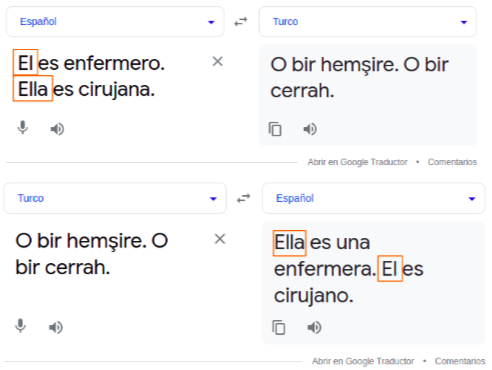


Source: [Google Blog](https://www.blog.google/products/translate/reducing-gender-bias-google-translate/), [Google AI Blog](https://ai.googleblog.com/2018/12/providing-gender-specific-translations.html)

Para ilustrar mejor la problemática tomemos un ejemplo particular: **traducción automática de texto**.


En poquísimas palabras, gran parte de los programas de traducción automática funcionan detectando patrones en cientos de millones de documentos que han sido previamente traducidos por humanos. Si bien estos sistemas no utilizan word embeddings directamente, conservan las mismas problemáticas: están basados en datos no estructurados escritos por personas, los cuales contienen sesgo.

Tomemos el ejemplo de arriba "*Él es enfermero. Ella es cirujana*". Cuando traducimos esta frase a un idioma con genero neutro como el turco, y volvemos al español, sucede que los pronombres cambian. Una posible explicación es la subprepresentación de los hombres en el área de la enfermería y de las mujeres en el la cirugía. Nuestro modelo entonces aprende de los datos que lo más probable es que la frase "O bir hemsire" se corresponda con "Ella es una enfermera" y "O bir cerrah" con Él es cirujano.

Más adelante en el taller, vamos a ver que sesgos de este tipo se pueden observar muy claramente en los word embeddings.



# Parte 2: Word Embeddings

## 2.1 ¿Qué es un word embedding?

A la hora de modelar el lenguaje, está claro que las palabras no son tan fáciles de representar de forma que conserven la complejidad del lenguaje humano. En el caso de las imágenes, por ejemplo, convertimos la misma en vectores que representan pixeles con intensidad, color, brillo, etc. Transformamos una imagen en un objeto matemático que las computadoras pueden manipular. Entonces ¿cómo podemos representar las palabras de manera
que una computadora pueda manipular?

Hay muchas formas de hacer esto, pero en este tutorial nos vamos a concentrar en word embeddings. Un word embedding es una representación aprendida para texto donde palabras con significados parecidos tienden a tener representaciones similares. Pero ¿qué significa que palabras tengan significados *parecidos*? ¿Cómo le "enseñamos" eso a una computadora?


**Hipótesis distribucional**

> "una palabra se caracteriza por su companía" - [John Rupert Firth](https://en.wikipedia.org/wiki/John_Rupert_Firth)

Basado en esta hipótesis, los word embeddings apuntan a representar palabras caracterizandolas por el contexto en donde ocurren, siguiendo los siguientes pasos:

1. Recolectar grandes cantidades de texto, por ejemplo, todos los articulos de la Wikipedia; después
2. descomponer el texto en todas las posibles combinaciones de palabras continuas, usando una *sliding-window* sobre el texto, por ejemplo si nuestro texto es: `El perro corre`, y utilizamos una ventana de tamaño 2 (esto sería el "tamaño del contexto"), descompondríamos el texto en: `El perro` y `perro corre`;
3. considerar cada una de estas sub-strings como ejemplos de entrenamiento para una red neuronal. Esta red trata de aprender como predecir el contexto dada una de las palabras en el substring, o trata de predecir una de las palabras dado el contexto, eso es, el resto de las palabras en el substring;
4. una vez que la red neuronal entrena en esos ejemplos, toma la penultima capa como el espacio en donde las palabras van a ser representadas, donde cada neurona en esa capa es una dimensión del espacio del embedding.

Si tenés más ganas de saber como funciona esto, [este post da una explicacion visual muy entendible](http://jalammar.github.io/illustrated-word2vec/).

Es importante notar que como los embeddings son obtenidos por texto creado por personas, naturalmente van a reflejar sus sesgos y prejuicios. No deberíamos tomarlos como objetivos o neutrales, sino como una construccion social que conserva las complejidades de nuestra sociedad.

## 2.1 Corpus y embedding para inglés


El embedding provisto por la librería [`responsibly`](http://docs.responsibly.ai) fue entrenado utilizando un corpus de GoogleNews con 100B palabras totales, 3 millones de palabras unicas, y vectores de 300 dimensiones.

La librería provee una versión reducida de este embedding, con las 50mil palabras más frecuentes. De estas 50mil se conservaron solamente las que estaban en minúscula, con menos de 20 caracteres, sin dígitos. Luego de este filtrado, filtrado el vocabulario resultante contiene 26,423 palabras.

Como se realizó después del proceso de entrenamiento, esta reducción en el tamaño del vocabulario no afecta la geometría del embedding.

***Nota:*** En esta primera parte, nuestro objeto de estudio va a ser el embedding word2vec entrenado en **inglés**. Vamos a introducir las técnicas en el idioma original para el cual fueron desarrolladas y luego mostraremos las dificultades que se presentan a la hora de adaptarlas al Español.


## 2.1 Corpus y embedding para inglés

El embedding que vamos a usar es **word2vec** entrenado sobre un corpus de Google News con 100B palabras, 3 millones de palabras en el vocabulario y 300 dimensiones. Es el mismo modelo de la librería `responsibly` original, pero descargado directamente desde el repositorio oficial de gensim.

Lo vamos a recortar a las 50,000 palabras más frecuentes para agilizar el análisis.


In [5]:
import gensim.downloader as api
import numpy as np

# Descargamos el modelo word2vec-google-news-300 (puede demorar unos minutos)
# Es el mismo corpus usado por responsibly, pero accedido directamente via gensim
print('Descargando modelo word2vec... (puede tardar unos minutos)')
w2v_full = api.load('word2vec-google-news-300')

# Normalizamos los vectores
w2v_full.init_sims(replace=True)

print('Modelo cargado!')
print(f'Vocabulario completo: {len(w2v_full.key_to_index)} palabras')

Descargando modelo word2vec... (puede tardar unos minutos)
[==================================================] 100.0% 1662.8/1662.8MB downloaded


Modelo cargado!
Vocabulario completo: 3000000 palabras


In [ ]:
# Tamaño del vocabulario
len(w2v_full.key_to_index)

3000000

In [ ]:
# Veamos como se ve el embedding de la palabra 'love'
print('love =', w2v_full['love'])

love = [ 0.03863575 -0.05712964  0.00970471  0.06189044 -0.06189044  0.02508577
  0.10986469 -0.09887822 -0.05273505  0.07544042 -0.00984205 -0.03076211
 -0.01039137 -0.0164797  -0.08825797  0.06372152  0.04834047  0.05896072
  0.00283817 -0.02618442 -0.01446552  0.02984658  0.08606067 -0.0538337
  0.06298909 -0.01318376  0.02069118  0.04010061  0.04193169 -0.06115801
 -0.04193169  0.05236884  0.00583656  0.04797425  0.05786207  0.02893104
  0.09814579  0.03241009 -0.00943005  0.12524575  0.06994719 -0.07873636
  0.02655063  0.00975049 -0.03991751 -0.03845264  0.04614317  0.0176699
  0.00828563  0.02188138 -0.04119926  0.05603099 -0.04010061  0.00583656
  0.03369184  0.0421148  -0.01638815 -0.04266412 -0.00140192 -0.00682077
  0.09118769  0.03167765 -0.02655063  0.0677499   0.01318376 -0.03625535
 -0.08239852 -0.00123026 -0.01199356  0.06921475  0.10693496 -0.03222698
 -0.04193169  0.00801097 -0.11499171 -0.03460738 -0.07104583  0.00567634
  0.06958097  0.1289079  -0.11645658  0.084595

No hay mucho que ver para nosotros humanos. Si bien los embeddings son extremadamente utiles, no son fáciles de interpretar. La codificacion de la semantica de las palabras no es transparente para los usuarios, no hay una relacion directa entre el valor de la coordenada del vector y algun significado particular de la palabra. Almacenan mucha información de forma críptica. Entonces, cómo podmeos observar/diagnosticar sesgo en word embeddings?

## 2.2 Midiendo distancia entre palabras

<img src="https://www.deeplearningitalia.com/wp-content/uploads/2018/11/imagen-3.png
" width="300"/>

### Métrica de similitud: [Similitud Coseno](https://es.wikipedia.org/wiki/Similitud_coseno)
- Mide el coseno del angulo entre dos vectores.
- El valor de la metrica se encuentra entre 1 (mismo vector) y -1 (vector opuesto)


In [ ]:
w2v_full['cat'] @ w2v_full['cat']

np.float32(1.0)

In [ ]:
w2v_full['cat'] @ w2v_full['dog']

np.float32(0.76094574)

In [ ]:
w2v_full['cat'] @ w2v_full['horse']

np.float32(0.38147905)

In [ ]:
w2v_full['cat'] @ w2v_full['the']

np.float32(0.07918914)

In [ ]:
w2v_full['cat'] @ w2v_full['finance']

np.float32(-0.037760593)

In [ ]:
w2v_full.most_similar('cat', topn=10)

[('cats', 0.8099379539489746),
 ('dog', 0.7609456777572632),
 ('kitten', 0.7464985251426697),
 ('feline', 0.7326233983039856),
 ('beagle', 0.7150583267211914),
 ('puppy', 0.7075453996658325),
 ('pup', 0.6934291124343872),
 ('pet', 0.6891531348228455),
 ('felines', 0.6755931377410889),
 ('chihuahua', 0.6709762215614319)]

### Encontremos la palabra que desentona

La función `doesnt_match` busca la palabra que "desentona", es decir la que está más lejos de todas las otras palabras según la distancia coseno.
Esto lo hace calculando el promedio entre todos los vectores y tomando el vector que se encuentra más alejado

In [ ]:
w2v_full.doesnt_match('hairdresser nurse man woman housekeeper personal_trainer'.split())

'nurse'

In [ ]:
# Será porque el contexto donde aparece la palabra 'nurse' es mas especifico de medicina?

In [ ]:
w2v_full.doesnt_match('hairdresser nurse man woman housekeeper manager'.split())

'manager'

In [ ]:
w2v_full.doesnt_match('hairdresser nurse man men housekeeper manager'.split())

'manager'

In [ ]:
w2v_full.doesnt_match('hairdresser nurse woman women housekeeper manager'.split())

'manager'



```
# This is formatted as code
```

## 2.3 Visualización del embedding utilizando T-SNE


Abajo podemos observar una visualizacion de los embeddings formada por una proyección de un espacio de 300 dimensiones a 2 dimensiones. Podemos ver que palabras con significados parecidos tienden a estar cerca, como por ejemplo `quality performance results` o `fans team players`.


In [ ]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

# Obtener las palabras más comunes en el corpus, entre la 200 y la 600
words = [word for word in w2v_full.index_to_key[200:600]]

# Convertirlas a vector
embeddings = [w2v_full[word] for word in words]

# T-SNE
words_embedded = TSNE(n_components=2, random_state=1).fit_transform(embeddings)

# Visualizar
plt.figure(figsize=(20, 20))
for i, label in enumerate(words):
    x, y = words_embedded[i, :]
    plt.scatter(x, y)
    plt.annotate(label, xy=(x, y), xytext=(5, 2), textcoords='offset points',
                 ha='right', va='bottom', size=11)
plt.show()

AttributeError: 'list' object has no attribute 'shape'

[Acá](http://projector.tensorflow.org/) tensorflow provee una herramienta para visualizar embeddings

## 2.4 Analogías de vectores

Una propiedad interesante sobre los word embeddings es que podemos generar analogías facilmente. Cómo lo hacemos? Por ejemplo, si queremos obtener una analogía de la forma "*hombre es a rey lo que mujer es a ?*", le restamos **hombre** a **rey + mujer**

Intuitivamente, estamos quitandole la parte de **hombre** a la combinacion entre un rey y una mujer.

<img src="https://github.com/ResponsiblyAI/word-embedding/blob/main/images/linear-relationships.png?raw=1" />

<small>Source: [Tensorflow Documentation](https://www.tensorflow.org/tutorials/representation/word2vec)</small>



Hay que tener en cuenta que el embedding fue generado aprendiendo las co-ocurrencias de palabras, entonces el hecho de que **empíricamente** muestre "aritmetica de conceptos" no signidica necesariamente que haya aprendido significados. De hecho, al parecer aprende más sobre cómo se comportan las palabras más que sus significados.

Ver: [king - man + woman is queen; but why? by Piotr Migdał](https://p.migdal.pl/2017/01/06/king-man-woman-queen-why.html)

In [ ]:
# small is to smaller as good is to what?
w2v_full.most_similar(positive=['good', 'smaller'], negative=['small'], topn=2)

[('better', 0.7270161509513855), ('stronger', 0.5597213506698608)]

In [ ]:
# man is to king what woman is to?
w2v_full.most_similar(positive=['king', 'woman'], negative=['man'], topn=2)

[('queen', 0.7118192911148071), ('monarch', 0.6189674139022827)]

In [ ]:
# man is to carpenter as woman is to what?
w2v_full.most_similar(positive=['carpenter', 'woman'], negative=['men'], topn=2)

[('schoolteacher', 0.5909148454666138), ('stone_mason', 0.572503924369812)]

Con estas analogías podemos empezar a **explorar** nuestro embedding para detectar posibles sesgos

# Parte 3: Explorando sesgo de género en inglés

Dado que la representación de una palabra en un embedding es un vector, ¿cómo podemos **observar** el sesgo? ¿Pueden los vectores estar sesgados? ¿Qué significa que un vector esté sesgado?


## 3.1 Palabras con género explícito en la morfología de la palabra

En inglés hay palabras que están fuertemente marcadas por género, por ejemplo **brother-sister**. Estas no necesariamente reflejan un estereotipo, si no más bien la construcción morfológica de la palabra. Otros ejemplos serían queen-king, mother-father, waiter-waitress.

In [ ]:
# She is to sister as he is to....
# sister - she + he = ?
w2v_full.most_similar(positive=['sister', 'he'], negative=['she'], topn=5)

[('brother', 0.7627109289169312),
 ('younger_brother', 0.6856131553649902),
 ('cousin', 0.6685014963150024),
 ('uncle', 0.6580696702003479),
 ('nephew', 0.6526023149490356)]

## 3.2 Palabras con estereotipos de género

En constrate, hay palabras que si bien no tienen una representación morfologica del género, tienen asociado algún genero por esterotipos presentes en nuestra sociedad. Esto pasa porque los contextos de ocurrencia de esas palabras estan sesgados hacia algun genero en especifico, reflejando como las personas utilizan esas palabras.
Algunas palabras que representan profesiones están fuertemente marcadas hacia algun genero porque tienden a ser asociadas con roles femeninos o masculinos. Vamos a explorar esas palabras utilizando analogías.

In [ ]:
# She is to interior designer as he is to what?
# interior_designer - she + he
w2v_full.most_similar(positive=['interior_designer', 'he'], negative=['she'], topn=4)

[('architect', 0.6232566237449646),
 ('craftsman', 0.5352414846420288),
 ('decorator', 0.520487368106842),
 ('landscape_architect', 0.504540741443634)]

In [ ]:
# He is to carpentry as she is to?
# carpentry - he + she
w2v_full.most_similar(positive=['carpentry', 'she'], negative=['he'], topn=4)

[('sewing', 0.5989980101585388),
 ('carpentry_plumbing', 0.5950644612312317),
 ('sewing_knitting', 0.5806261301040649),
 ('carpentry_welding', 0.5778024792671204)]

In [ ]:
w2v_full.most_similar(positive=['doctor', 'she'], negative=['he'], topn=4)

[('nurse', 0.6588720679283142),
 ('gynecologist', 0.647172212600708),
 ('nurse_practitioner', 0.6255376935005188),
 ('midwife', 0.600278377532959)]

In [ ]:
# She is to ___ as he is to ?
w2v_full.most_similar(positive=['nurse', 'he'], negative=['she'], topn=4)

[('doctor', 0.5559605360031128),
 ('medic', 0.5425376892089844),
 ('physician', 0.5394271016120911),
 ('x_ray_technician', 0.5355569124221802)]

In [ ]:
# He is to ___ as she is to ?
w2v_full.most_similar(positive=['____', 'she'], negative=['he'], topn=4)

[('_____', 0.5303619503974915),
 ('shes', 0.5230785608291626),
 ('______', 0.5207394361495972),
 ('W_ealthy', 0.5126332640647888)]

Acá hay otras palabras comunmente estereotipadas que pueden explorar.

```
nurse-doctor
sewing-carpentry
volleyball-football
interior_designer-architect
feminism-conservatism
vocalist-guitarist
diva-superstar
cupcakes-pizzas
hairdresser-barber
```

**Nota:** Tener en cuenta que estamos realizando un **análisis exploratorio** sobre los datos!

## 3.3 Dirección del género
Ahora, veamos un ejemplo de como podemos representar significado binario.
Tomemos nuestra representacióń binaria del significado de género.

### $\overrightarrow{ella} - \overrightarrow{él}$


In [ ]:
from numpy.linalg import norm

gender_direction = w2v_full['she'] - w2v_full['he']
gender_direction /= norm(gender_direction)

In [ ]:
# el operador @ devuelve la distancia entre 2 vectores normalizados
gender_direction @ w2v_full['architect']

np.float32(-0.16785535)

In [ ]:
gender_direction @ w2v_full['interior_designer']

np.float32(0.19714229)

In [ ]:
# Y con otra representación?
gender_direction = w2v_full['queen'] - w2v_full['king']

gender_direction /= norm(gender_direction)

In [ ]:
gender_direction @ w2v_full['architect']

np.float32(-0.06887732)

In [ ]:
gender_direction @ w2v_full['interior_designer']

np.float32(0.15392676)

**⚡Interpretar con precaución: La palabra *architect* aparece en más contextos con *he* que con *she*, y viceversa para *interior designer*.**

En la práctica, para calcular la dirección del subespacio de genero se utilizan más palabras que "he" y "she". Como las palabras pueden tener multiples significados y no solamente los asociados al género, utilizamos más palabras que representen los dos "extremos". Esto permite una mejor estimación.

- woman - man
- girl - boy
- she - he
- mother - father
- daughter - son
- gal - guy
- female - male
- her - his
- herself - himself
- Mary - John

Notemos que esta lista de palabras es una parte **muy** importante del análisis ya que define el significado del sesgo que queremos explorar.

## 3.4 Probamos algunas palabras


Ahora revisemos algunas palabras: donde se situa en la dirección del género? cercano a cual extremo, y qué tan cercana?

⚡ A tener en cuenta: estamos realizando análisis exploratorio, no una evaluacion sistemática!

In [ ]:
gender_direction @ w2v_full['house']

np.float32(0.037528906)

In [ ]:
gender_direction @ w2v_full['home']

np.float32(-0.048104018)

## 3.5 Proyecciones en la dirección del género

Ahora queremos darle **sistematicidad** a este análisis exploratorio.

Vamos a usar una lista de profesiones morfologicamente neutrales.
Estas palabras deberían ubicarse equidistantes de ambos extremos en la dirección del genero. Decimos que su bias debería ser alrededor de 0, y de nuevo, tenemos un módulo de alto nivel que nos provee esa funcionalidad:

In [ ]:
# Reemplazamos la clase GenderBiasWE de responsibly con implementación propia
import numpy as np
from numpy.linalg import norm
import matplotlib.pyplot as plt

class GenderBiasWE:
    """
    Implementación simplificada de GenderBiasWE equivalente a la de responsibly.
    """
    def __init__(self, model, positive_end='she', negative_end='he', only_lower=True):
        self.model = model
        self.positive_end = positive_end
        self.negative_end = negative_end
        self.only_lower = only_lower
        # Calcular la dirección de género
        v_pos = model[positive_end]
        v_neg = model[negative_end]
        direction = v_pos - v_neg
        self.direction = direction / norm(direction)

    def project_on_direction(self, word):
        """Proyecta una palabra sobre la dirección de género"""
        if self.only_lower:
            word = word.lower()
        return float(self.model[word] @ self.direction)

    def calc_direct_bias(self, neutral_words=None, c=1):
        """Calcula el sesgo directo promedio sobre una lista de palabras neutras"""
        if neutral_words is None:
            neutral_words = BOLUKBASI_DATA_neutral
        projections = []
        for word in neutral_words:
            try:
                proj = self.project_on_direction(word)
                projections.append(proj)
            except KeyError:
                pass
        abs_projections = [abs(p) for p in projections]
        return sum(abs_projections) / len(abs_projections)

    def plot_projection_scores(self, words=None, n_extreme=10, ax=None):
        """Grafica las proyecciones de palabras en la dirección de género"""
        if words is None:
            words = BOLUKBASI_DATA_neutral
        scores = {}
        for word in words:
            try:
                scores[word] = self.project_on_direction(word)
            except KeyError:
                pass
        sorted_words = sorted(scores.items(), key=lambda x: x[1])
        # Tomamos los n_extreme más extremos de cada lado
        to_plot = sorted_words[:n_extreme] + sorted_words[-n_extreme:]
        to_plot_words = [w for w, s in to_plot]
        to_plot_scores = [s for w, s in to_plot]
        if ax is None:
            fig, ax = plt.subplots(figsize=(10, 8))
        colors = ['#d73027' if s > 0 else '#4575b4' for s in to_plot_scores]
        ax.barh(to_plot_words, to_plot_scores, color=colors)
        ax.axvline(x=0, color='black', linewidth=0.8)
        ax.set_xlabel(f'← {self.negative_end}                {self.positive_end} →')
        ax.set_title('Proyección en dirección de género')
        plt.tight_layout()

    def generate_closest_words_indirect_bias(self, word1, word2, topn=10):
        """Muestra palabras cercanas a word1 vs word2 y su sesgo de género"""
        neighbors1 = [w for w, _ in self.model.most_similar(word1, topn=topn)]
        neighbors2 = [w for w, _ in self.model.most_similar(word2, topn=topn)]
        all_words = list(set(neighbors1 + neighbors2 + [word1, word2]))
        result = {}
        for w in all_words:
            try:
                result[w] = self.project_on_direction(w)
            except KeyError:
                pass
        return sorted(result.items(), key=lambda x: x[1], reverse=True)


# Lista de profesiones neutras de Bolukbasi et al. (hardcodeada para no depender de responsibly)
BOLUKBASI_DATA_neutral = [
    'janitor', 'statistician', 'midwife', 'bailiff', 'auctioneer', 'photographer',
    'geologist', 'shoemaker', 'athlete', 'cashier', 'dancer', 'housekeeper',
    'accountant', 'physicist', 'gardener', 'dentist', 'weaver', 'blacksmith',
    'psychologist', 'supervisor', 'mathematician', 'surveyor', 'tailor', 'designer',
    'economist', 'mechanic', 'laborer', 'novelist', 'hairdresser', 'volunteer',
    'teacher', 'architect', 'singer', 'electrician', 'expert', 'doctor', 'pilot',
    'manager', 'housemaker', 'diplomat', 'scientist', 'climber', 'instructor',
    'librarian', 'sheriff', 'artist', 'comedian', 'farmer', 'pharmacist', 'plumber',
]

w2v_small_gender_bias = GenderBiasWE(w2v_full, only_lower=True)
print('GenderBiasWE inicializado correctamente')

GenderBiasWE inicializado correctamente


In [ ]:
w2v_small_gender_bias.positive_end, w2v_small_gender_bias.negative_end

('she', 'he')

In [ ]:
# gender direction
w2v_small_gender_bias.direction[:10]

array([-0.07815727, -0.09911115, -0.05145978, -0.00130573,  0.04661367,
       -0.01718594,  0.03149417,  0.00793875, -0.14925967,  0.02721609],
      dtype=float32)

In [ ]:
# Lista de profesiones morfológicamente neutras (Bolukbasi et al.)
neutral_profession_names = BOLUKBASI_DATA_neutral

In [ ]:
neutral_profession_names[:10]

['janitor',
 'statistician',
 'midwife',
 'bailiff',
 'auctioneer',
 'photographer',
 'geologist',
 'shoemaker',
 'athlete',
 'cashier']

In [ ]:
len(neutral_profession_names)

50

In [ ]:
# lo mismo que usar el operador @ en la dirección del género
w2v_small_gender_bias.project_on_direction(neutral_profession_names[0])

Visualicemos la proyección de las profesiones (neutras y con género) en la dirección del género:

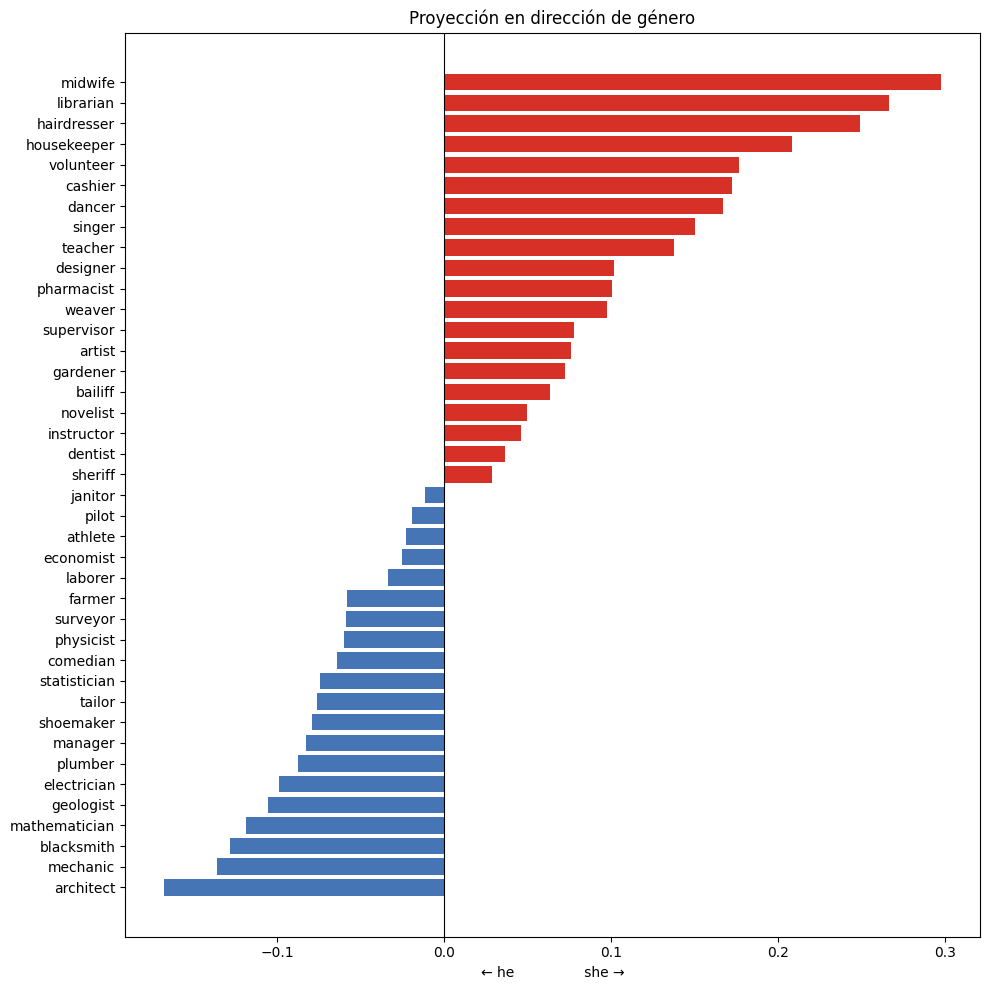

In [ ]:
import matplotlib.pyplot as plt

f, ax = plt.subplots(1, figsize=(10, 10))
w2v_small_gender_bias.plot_projection_scores(n_extreme=20, ax=ax)
plt.show()

## 3.6 Medida del sesgo
Ahora que modelamos la dirección del genero (con palabras representando cada extremo) y tenemos una idea de cómo debería verse un embedding "sin sesgo", podemos diagnosticar el sesgo de una manera simple y sistemática:

1. Proyectar cada **profesión neutra** en su dirección de género
2. Calcular el valor absoluto de cada proyección
3. Promediarlo entre todas las palabras

In [ ]:
# funcion para calcular el sesgo
w2v_small_gender_bias.calc_direct_bias()

0.08549083270161051

In [ ]:
# Calculamos el sesgo directamente:
neutral_profession_projections = [w2v_full[word] @ w2v_small_gender_bias.direction
                                  for word in neutral_profession_names
                                  if word in w2v_full.key_to_index]

abs_neutral_profession_projections = [abs(proj) for proj in neutral_profession_projections]

sum(abs_neutral_profession_projections) / len(abs_neutral_profession_projections)

np.float32(0.08549083)

¿Sobre qué asunciones funciona la medición directa del sesgo? ¿Cómo afecta la elección de las palabras neutras a la definición del sesgo? ¿Podemos medir **todo** el sesgo de género con esta técnica?

Una propiedad interesante de este método es que nos da una medida cuantitiativa del sesgo en el embedding, pero hay que tener en cuenta que este número sólo tiene en cuenta el sesgo presente en las palabras que *hemos incluido en la lista de palabras neutras* con respecto a la *dirección del género*, que acordamos es una simplificación del fenómeno.

¿Qué pasa con las palabras que no están en la lista? Esta lista, ¿es lo suficientemente exhaustiva?

In [ ]:
w2v_small_gender_bias.generate_closest_words_indirect_bias('softball', 'football')

[('volleyball', 0.23678699135780334),
 ('softball', 0.23635748028755188),
 ('SOFTBALL', 0.23635748028755188),
 ('Softball', 0.23635748028755188),
 ('fastpitch', 0.1578202098608017),
 ('fastpitch_softball', 0.13429179787635803),
 ('softballers', 0.12129966914653778),
 ('slowpitch', 0.08730169385671616),
 ('basketball', 0.04787802696228027),
 ('athletics', 0.03580494597554207),
 ('soccer', 0.018332019448280334),
 ('footballl', -0.05750724673271179),
 ('sports', -0.08416733890771866),
 ('baseball', -0.09383445233106613),
 ('gridiron', -0.10336724668741226),
 ('footbal', -0.1155211329460144),
 ('fooball', -0.19374200701713562),
 ('football', -0.20827805995941162),
 ('Football', -0.20827805995941162)]

EXTRA: Demo - Visualizing gender bias with [Word Clouds](http://wordbias.umiacs.umd.edu/)

# Parte 4: Explorando sesgo de género en castellano

Vamos a ver ahora cómo se trasladan al castellano estas técnicas pensadas para el inglés.

El castellano es una lengua con varias diferencias con respecto al inglés:
- la mayoría de las palabras tienen **género marcado explícitamente en su forma**. Por lo tanto, será difícil obtener una lista de palabras neutras con respecto al género, que responsibly define muy fácilmente para el inglés.
- se pueden **omitir los sujetos** de las oraciones, por lo tanto, las ocurrencias de "*él*" y "*ella*" tendrán una distribución muy diferente que las de "*he*" y "*she*".
Con estas diferencias **¿resultarán efectivas las estrategias desarrolladas para el inglés?**

Vamos a analizar los [word embeddings para el castellano](http://dcc.uchile.cl/~jperez/word-embeddings/fasttext-sbwc.vec.gz) obtenidos mediante [fastText](https://fasttext.cc/) a partir del [Spanish Billion Words Corpus](https://github.com/crscardellino/sbwce). Este embedding representa 855.380 palabras en 300 dimensiones, obteniendo sus contextos de ocurrencia a partir de 1'4 billones de palabras. Para este ejemplo usaremos solamente las 100000 palabras más frecuentes, así se ejecutará todo más rápido.

A diferencia de los embeddings obtenidos con word2vec, los embeddings obtenidos con fastText procesan también cadenas de caracteres dentro de las palabras, lo cual es muy adecuado para modelar lenguas donde las palabras tienen muchas variaciones en la forma, como el castellano, que es una [lengua de tipología fusionante](https://es.wikipedia.org/wiki/Lengua_fusionante). Efectivamente, mientras que en inglés (una [lengua aislante](https://es.wikipedia.org/wiki/Lengua_aislante)) las palabras tienen pocas formas diferentes, en castellano las palabras tienen muchas, porque significados como género, número, o tiempo verbal se expresan como variaciones en la forma de la palabra: "*escribirá, escribiremos, escribirían*".

Empecemos por obtener datos y librerías.

In [ ]:
# Descargar el modelo e importar librerías necesarias
# Usamos el mismo modelo fasttext de SBWC (Spanish Billion Words Corpus)
import numpy as np
import logging
from numpy.linalg import norm
from gensim.models import KeyedVectors

logging.basicConfig(format='%(asctime)s : %(message)s', level=logging.INFO)

!wget -q http://dcc.uchile.cl/~jperez/word-embeddings/fasttext-sbwc.100k.vec.gz
!gzip -d -q fasttext-sbwc.100k.vec.gz
!ls

fasttext-sbwc.100k.vec	sample_data


In [ ]:
embedding = KeyedVectors.load_word2vec_format('fasttext-sbwc.100k.vec')
# Normalizar los vectores (método actualizado para gensim 4+)
embedding.fill_norms(force=True)
print('Modelo en español cargado y normalizado!')
print(f'Vocabulario: {len(embedding.key_to_index)} palabras')

Modelo en español cargado y normalizado!
Vocabulario: 100000 palabras


In [ ]:
# Todos los vectores deberían tener norma 1, o cercana a 1
from numpy.testing import assert_almost_equal
import numpy as np

# Calculamos las normas manualmente
sample_words = list(embedding.key_to_index.keys())[:100]
sample_vectors = np.array([embedding[w] for w in sample_words])
length_vectors = norm(sample_vectors, axis=1)

print('Norma mínima:', length_vectors.min())
print('Norma máxima:', length_vectors.max())
print('Norma promedio:', length_vectors.mean())

Norma mínima: 1.7399883
Norma máxima: 4.686321
Norma promedio: 2.9413576


## 4.1 Palabras con estereotipos de género

En castellano casi todas las palabras tienen género explícito en la morfología de la palabra (como "gato", que sabemos que es masculino por su ofrma), así que vamos a centrarnos directamente en las que reflejan estereotipos de género.

Vemos que la aritmética de vectores produce unos resultados bastante comparables a los del inglés.

In [ ]:
embedding.most_similar(positive=['soldado'],negative=['ejército'])

[('chaval', 0.3067452013492584),
 ('puñal', 0.3004051446914673),
 ('muchacho', 0.2909274101257324),
 ('trozo', 0.28779613971710205),
 ('punzante', 0.2872093915939331),
 ('cosida', 0.28195783495903015),
 ('clava', 0.27909067273139954),
 ('gracioso', 0.27801963686943054),
 ('chispeante', 0.27694645524024963),
 ('clavado', 0.27669188380241394)]

In [ ]:
embedding.most_similar(positive=['médica'],negative=['hombre'])

[('odontológica', 0.4673573672771454),
 ('medica', 0.4480203092098236),
 ('oftalmológica', 0.43779072165489197),
 ('pediátrica', 0.4357350468635559),
 ('obstetricia', 0.4247724413871765),
 ('ambulatoria', 0.4196279048919678),
 ('ambulatorios', 0.41067975759506226),
 ('oftalmología', 0.4102064073085785),
 ('pediatría', 0.4018036723136902),
 ('psiquiátrica', 0.38612356781959534)]

A pesar de las diferencias entre el castellano y el inglés, podemos ver en la exploración del embedding fenómenos comparables.

Se evidencian nociones estereotípicas sobre especialidades médicas, asociando a las doctoras más con especialidades médicas relacionadas comunmente asociadas a las mujeres, tal como psicología, biología, enfemería, mientras que los doctores están mas relacionados con profesor, investigador, catedrático...

Podemos seguir explorando cómo el uso de las palabras refleja estereotipos.

In [ ]:
# hombre es a inteligente lo que mujer es a.....
# inteligente - hombre + mujer
embedding.most_similar(positive=['inteligente', 'mujer'], negative=['hombre'])

[('sensata', 0.4874056875705719),
 ('talentosa', 0.48738619685173035),
 ('innovadora', 0.4754442870616913),
 ('manipuladora', 0.47190895676612854),
 ('emprendedora', 0.46958670020103455),
 ('atractiva', 0.45731812715530396),
 ('extrovertida', 0.4571164846420288),
 ('impulsiva', 0.44972625374794006),
 ('educada', 0.4474370777606964),
 ('ingeniosa', 0.44558414816856384)]

In [ ]:
# mujer es a inteligente, lo que hombre es a
# inteligente - mujer + hombre
embedding.most_similar(positive=['inteligente', 'hombre'], negative=['mujer'])

[('astuto', 0.598764955997467),
 ('inteligentemente', 0.5654456615447998),
 ('inteligentes', 0.5556884407997131),
 ('intuitivo', 0.5533122420310974),
 ('visionario', 0.5499666333198547),
 ('bondadoso', 0.5497375726699829),
 ('afable', 0.5486627221107483),
 ('disciplinado', 0.5481559634208679),
 ('honesto', 0.5480844378471375),
 ('ingenioso', 0.5475455522537231)]

El espacio no es simétrico!

In [ ]:
# Hombre es a belleza lo que mujer es a....
# belleza - hombre + mujer
embedding.most_similar(positive=['crecimiento','mujer'], negative=['hombre'])

[('crecimientos', 0.536388099193573),
 ('decrecimiento', 0.5073877573013306),
 ('reactivación', 0.5007616281509399),
 ('desaceleración', 0.4915383458137512),
 ('desarrollo', 0.4743867516517639),
 ('desacelerado', 0.47264477610588074),
 ('inflación', 0.4702436625957489),
 ('desacelera', 0.46959149837493896),
 ('ralentización', 0.4675186276435852),
 ('macroeconómico', 0.467083215713501)]

In [ ]:
# Mujer es a belleza lo que hombre es a
# belleza - mujer + hombre
embedding.most_similar(positive=['crecimiento','hombre'], negative=['mujer'])

[('decrecimiento', 0.6435226798057556),
 ('crecimientos', 0.5896702408790588),
 ('crecer', 0.5147644877433777),
 ('desacelerado', 0.5121310353279114),
 ('expansión', 0.5059387683868408),
 ('expansivo', 0.5047085881233215),
 ('incremento', 0.5018993020057678),
 ('declive', 0.5013155341148376),
 ('crecerá', 0.5002662539482117),
 ('repunte', 0.49099889397621155)]

## 4.2 Dirección del género

Ahora vamos a construir el espacio de género! Empecemos como en inglés, con "*él*" y "*ella*".

In [ ]:
# Implementación de BiasWordEmbedding equivalente a la de responsibly
class BiasWordEmbedding:
    """
    Implementación simplificada de BiasWordEmbedding equivalente a la de responsibly.
    """
    def __init__(self, model, only_lower=True):
        self.model = model
        self.only_lower = only_lower
        self.direction = None
        self.positive_end = None
        self.negative_end = None

    def _identify_direction(self, positive_label, negative_label, definitional, method='sum'):
        """Calcula la dirección de sesgo a partir de pares de palabras"""
        self.positive_end = positive_label
        self.negative_end = negative_label
        positive_words, negative_words = definitional
        if method == 'sum':
            v_pos = np.sum([self.model[w] for w in positive_words if w in self.model.key_to_index], axis=0)
            v_neg = np.sum([self.model[w] for w in negative_words if w in self.model.key_to_index], axis=0)
            direction = v_pos - v_neg
        self.direction = direction / norm(direction)
        print(f'Dirección de sesgo calculada: {positive_label} vs {negative_label}')

    def project_on_direction(self, word):
        """Proyecta una palabra sobre la dirección de sesgo"""
        if self.only_lower:
            word = word.lower()
        return float(self.model[word] @ self.direction)

    def calc_direct_bias(self, neutral_words, c=None):
        """Calcula el sesgo directo promedio"""
        projections = []
        for word in neutral_words:
            try:
                proj = self.project_on_direction(word)
                projections.append(proj)
            except KeyError:
                pass
        abs_projections = [abs(p) for p in projections]
        return sum(abs_projections) / len(abs_projections)

    def plot_projection_scores(self, words, n_extreme=10, ax=None):
        """Grafica las proyecciones de palabras en la dirección de sesgo"""
        scores = {}
        for word in words:
            try:
                proj = self.project_on_direction(word)
                scores[word] = proj
            except KeyError:
                pass
        sorted_words = sorted(scores.items(), key=lambda x: x[1])
        to_plot = sorted_words[:n_extreme] + sorted_words[-n_extreme:]
        to_plot = list(dict(to_plot).items())  # deduplicar
        to_plot_words = [w for w, s in to_plot]
        to_plot_scores = [s for w, s in to_plot]
        if ax is None:
            fig, ax = plt.subplots(figsize=(10, 8))
        colors = ['#d73027' if s > 0 else '#4575b4' for s in to_plot_scores]
        ax.barh(to_plot_words, to_plot_scores, color=colors)
        ax.axvline(x=0, color='black', linewidth=0.8)
        ax.set_xlabel(f'← {self.negative_end}                {self.positive_end} →')
        ax.set_title('Proyección en dirección de sesgo')
        plt.tight_layout()


embedding_sesgo = BiasWordEmbedding(embedding, only_lower=True)
print('BiasWordEmbedding inicializado')

BiasWordEmbedding inicializado


In [ ]:
espacio_f = ['ella']
espacio_m = ['él']

embedding_sesgo._identify_direction('Femenino', 'Masculino',
                                    definitional=(espacio_f, espacio_m),
                                    method='sum')

Dirección de sesgo calculada: Femenino vs Masculino


In [ ]:
direccion_sesgo = embedding_sesgo.direction
direccion_sesgo /= norm(direccion_sesgo)

In [ ]:
direccion_sesgo @ embedding['arquitecta']

np.float32(0.9911416)

In [ ]:
direccion_sesgo @ embedding['arquitecto']

np.float32(-0.4156275)

⚡ El castellano es una [lengua que permite la omisión del sujeto](https://en.wikipedia.org/wiki/Pro-drop_language), por lo tanto **"*él*" y "*ella*" ocurren menos veces y en contextos muy distintos a "*he*" y "*she*". Quizás no son buenos delimitadores del subespacio de género...**

Probemos qué pasa usando más y mejores indicadores.

In [ ]:
espacio_f = ['mujer', 'ella', 'chica', 'niña', 'esposa', 'señora', 'hermana', 'madre', 'abuela']
espacio_m = ['hombre', 'él', 'chico', 'niño', 'esposo', 'señor', 'hermano', 'padre', 'abuelo']

embedding_sesgo._identify_direction('Femenino', 'Masculino',
                                    definitional=(espacio_f, espacio_m),
                                    method='sum')

Dirección de sesgo calculada: Femenino vs Masculino


In [ ]:
direccion_sesgo = embedding_sesgo.direction
direccion_sesgo /= norm(direccion_sesgo)

Ahora probemos dónde se sitúan algunas palabras en este espacio de sesgo.

In [ ]:
direccion_sesgo @ embedding['arquitecta']

np.float32(1.6203142)

In [ ]:
direccion_sesgo @ embedding['arquitecto']

np.float32(-0.6246212)

In [ ]:
direccion_sesgo @ embedding['arquitectura']

np.float32(0.17183787)

In [ ]:
direccion_sesgo @ embedding['ingeniería']

np.float32(-0.14744729)

In [ ]:
direccion_sesgo @ embedding['obstetricia']

np.float32(0.503368)

In [ ]:
direccion_sesgo @ embedding['medicina']

np.float32(0.079409756)

Todas estas palabras tienen género gramatical femenino, pero
parecen ubicarse del lado masculino.

Podríamos pensar que la posición en la dirección del género en castellano solamente tiene que ver con el género gramatical de la palabra, pero no parece ser así!

Por lo tanto, parece que hemos podido llegar a una representación de la dirección de género que es indicativa de estereotipos de género.


## 4.3 Medida del sesgo

Como en inglés, podemos medir el sesgo de un embedding si hemos definido:

a) la dirección de sesgo

b) una lista de palabras que deberían ser neutras con respecto al sesgo, es decir, que no tengan género morfológicamente marcado.

La librería responsibly provee una lista de profesiones neutras en inglés. En español, la lista de profesiones neutras es mucho más corta porque en castellano la mayor parte de las palabras tienen género morfológicamente marcado.

Sin embargo, hay algunas profesiones que tienen forma no marcada con género, principalmente palabras terminadas en -ista, -nte.

Con esta lista, la estrategia desarrollada para el inglés debería
funcionar.

En este [repositorio pueden](https://github.com/git-lu/palabras-neutras) descargarse una lista mucho más exhaustiva de palabras con género neutro en español.


Nota: existen otras aproximaciones, descriptivamente más adecuadas pero técnicamente más complejas, para tratar sesgo de género en lenguas con género morfológicamente marcado, como por ejemplo Zhou, P., Shi, W., Zhao, J., Huang, K. H., Chen, M., & Chang, K. W. [Analyzing and Mitigating Gender Bias in Languages with Grammatical Gender and Bilingual Word Embeddings](https://aiforsocialgood.github.io/icml2019/accepted/track1/pdfs/47_aisg_icml2019.pdf). ICML 2019 - AI for Social Good. [Poster](https://aiforsocialgood.github.io/icml2019/accepted/track1/posters/47_aisg_icml2019.pdf)

In [ ]:
profesiones_neutras = [
    'chofer',
    'columnista',
    'publicista',
    'naturista',
    'asistente',
    'taxista',
    'psiquiatra',
    'policia',
    'dentista',
    'florista',
    'docente',
    'periodista',
    'electricista',
    'economista',
    'atleta',
    'terapeuta',
    'piloto',
    'modelo',
    'estudiante',
    'comerciante',
    'chef',
    'cantante',
    'militar',
]

Para medir el sesgo usamos esta lista de profesiones neutras de la siguiente forma:

1. Proyectamos cada uno de los nombres de profesión neutros en la dirección de género
2. Calculamos el valor absoluto de cada proyección
3. Lo promediamos

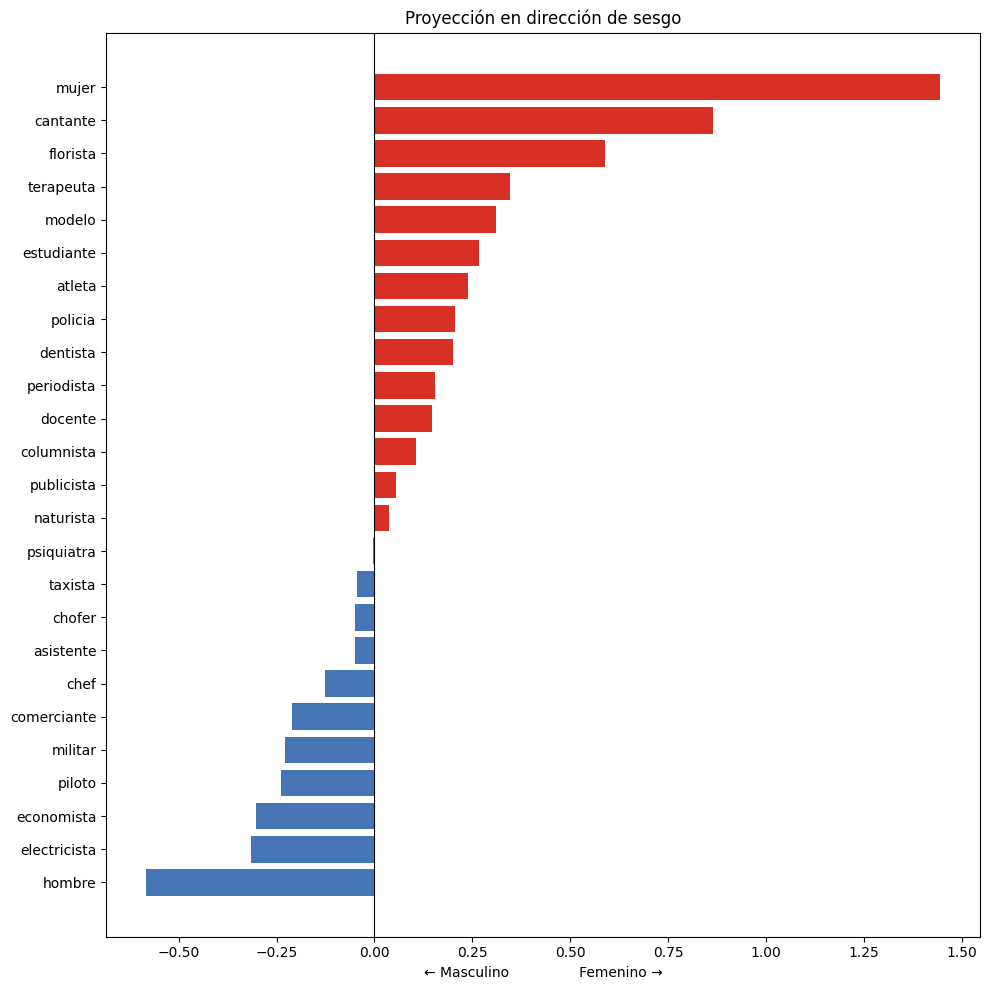

In [ ]:
import matplotlib.pyplot as plt

f, ax = plt.subplots(1, figsize=(10, 10))

embedding_sesgo.plot_projection_scores(
    profesiones_neutras + espacio_f[:1] + espacio_m[:1],
    n_extreme=20,
    ax=ax)
plt.show()

In [ ]:
embedding_sesgo.calc_direct_bias(profesiones_neutras, c=None)

0.22174498662555023

## 4.4 Palabras de género semántico neutro para el castellano

En inglés hay muchas palabras neutras con respecto al género, porque es una lengua que no tiene género marcado explícitamente en la morfología de la palabra, excepto en casos excepcionales.

En cambio, en castellano la mayor parte de las palabras tienen género morfológicamente marcado. Sin embargo, podemos apoyarnos en algunas sistematicidades para conseguir listas de palabras neutras:

* Palabras de categorías gramaticales sin género: verbos, adverbios, preposiciones
* Palabras abstractas, cuyo género morfológico no tiene una correspondencia con un género semántico
* Palabras de colectivos, igual
* Más palabras sin género marcado morfológicamente, como las terminadas en -ble, -nte

### Categorías gramaticales sin género

In [ ]:
verbos = [
          'comprar',
          'vender',
          'dormir',
          'despertar',
          'soñar',
          'llorar',
          'gritar',
          'hablar',
          'preguntar',
          'pensar',
          'inventar',
          'bailar',
          'cantar',
          'cocinar',
          'sentir',
          'bordar',
          'tejer',
          'coser',
          'razonar',
          'argumentar',
          'cursar',
          'programar'
]

In [ ]:
f, ax = plt.subplots(1, figsize=(10, 10))

embedding_sesgo.plot_projection_scores(
    verbos + ['hombre'] + ['mujer'],
    n_extreme=20,
    ax=ax)
plt.show()

### Colectivos

Las palabras referidas a colectivos se han usado muchas veces en lenguaje igualitario, porque, aunque tienen género morfológico, ese género no se corresponde con el género de las personas que componen el colectivo.

Podríamos usar las palabras de colectivos profesionales también como indicadores de género neutro!

In [ ]:
profesiones_colectivos = [
'ingeniería',
'arquitectura',
'psicología',
'enfermería',
'medicina',
'carpintería',
'presidencia',
'biología',
'cocina',
'docencia',
'abogacía',
'cirugía',
'neurocirugía',
'actuación',
'música',
'canto'
]

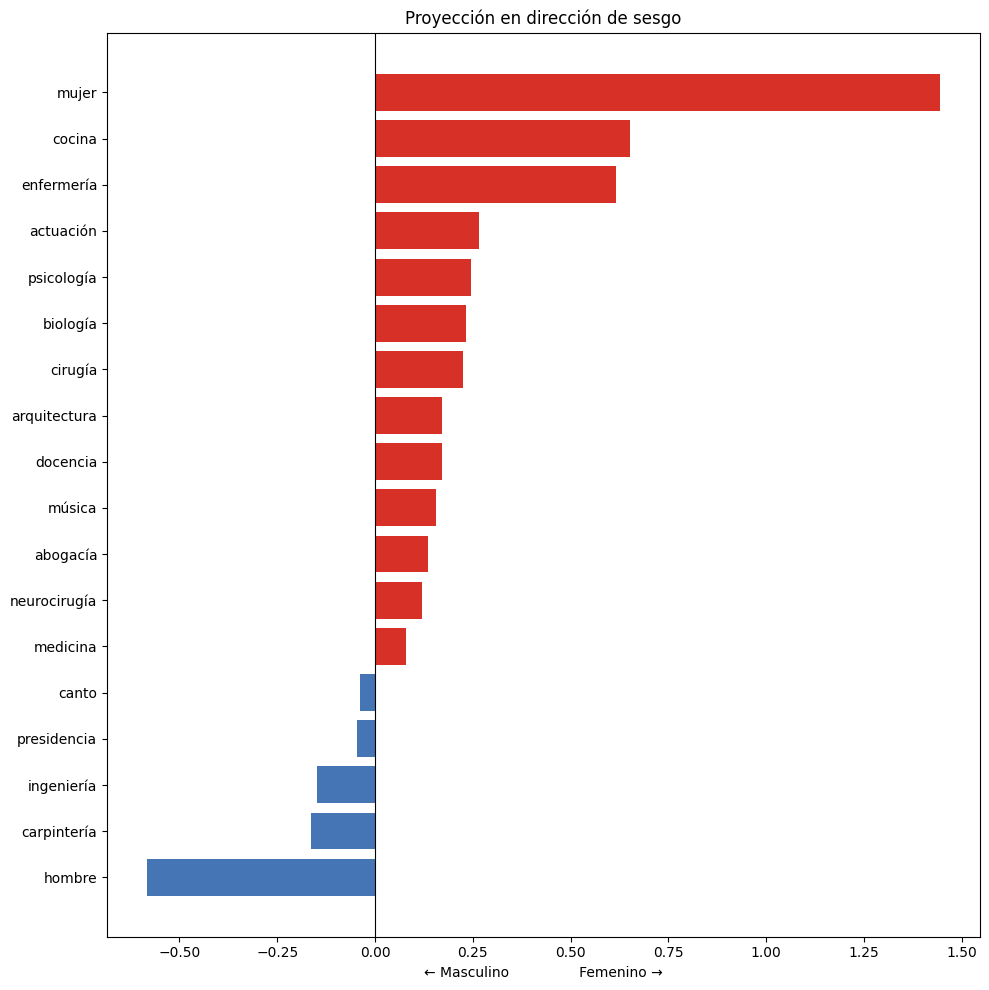

In [ ]:
f, ax = plt.subplots(1, figsize=(10, 10))

embedding_sesgo.plot_projection_scores(
    profesiones_colectivos + ['hombre'] + ['mujer'],
    n_extreme=20,
    ax=ax)
plt.show()

### Sustantivos abstractos

In [ ]:
sustantivos_abstractos = [
'inteligencia',
'belleza',
'humildad',
'sabiduría',
'poder',
'cariño',
'bondad',
'ambición',
'delicadeza',
'amabilidad',
'paciencia',
'popularidad',
'fama',
'generosidad',
'honestidad',
'canto',
'maldad',
'soberbia',
'violencia'
]


In [ ]:
f, ax = plt.subplots(1, figsize=(10, 10))

embedding_sesgo.plot_projection_scores(
    sustantivos_abstractos + ['hombre'] + ['mujer'],
    n_extreme=20,
    ax=ax)
plt.show()

### Adjetivos neutros

In [ ]:
adjetivos_neutros = [
'inteligente',
'humilde',
'amable',
'dulce',
'audaz',
'paciente',
'popular',
'flexible',
'grande',
'brillante',
'inocente',
'fácil',
'agradable',
'infeliz',
'capaz',
'difícil',
'temperamental',
]

In [ ]:
f, ax = plt.subplots(1, figsize=(10, 10))

embedding_sesgo.plot_projection_scores(
    adjetivos_neutros + ['hombre'] + ['mujer'],
    n_extreme=20,
    ax=ax)
plt.show()

## 4.5 ¿Podemos incorporar palabras con género morfológico marcado?

¿Habrá alguna forma de incorporar las palabras con género marcado morfológicamente?

Veamos algunas de sus propiedades

In [ ]:
palabras_con_genero = ['gato','gata']

In [ ]:
f, ax = plt.subplots(1, figsize=(10, 2))

embedding_sesgo.plot_projection_scores(
    palabras_con_genero + espacio_f[:1] + espacio_m[:1],
    n_extreme=20,
    ax=ax)
plt.show()

In [ ]:
profesiones_con_genero = [
                          'arquitecta', 'arquitecto',
                          'ingeniera', 'ingeniero',
                          'diseñadora', 'diseñador',
                          'doctor', 'doctora',
                          'abogada', 'abogado',
                          'profesor', 'profesora',
                          'contador','contadora',
                          'científico', 'científica',
                          'biólogo', 'bióloga',
                          'cocinera', 'cocinero',
                          'psicóloga','psicólogo',
                          'enfermera', 'enfermero',
                          'obrera', 'obrero',
                          'actor', 'actriz'
                          ]

In [ ]:
f, ax = plt.subplots(1, figsize=(10, 10))

embedding_sesgo.plot_projection_scores(
    profesiones_con_genero + espacio_f[:1] + espacio_m[:1],
    n_extreme=20,
    ax=ax)
plt.show()

Las profesiones con género morfológico femenino están más hacia el lado femenino que las profesiones masculinas hacia el lado masculino.

Esto ya lo notan Zhou et al. [Examining Gender Bias in Languages with Grammatical Gender](https://www.aclweb.org/anthology/D19-1531/) EMNLP 2019.


Podemos buscar otra forma de calcular el sesgo cuando la mayoría de las palabras tienen una forma femenina y otra masculina: podemos medir el sesgo como el valor absoluto de la diferencia entre la proyección de cada palabra. Cuanto más grande sea esa diferencia, más estereotipada hacia uno de los dos géneros está esa profesión.

In [ ]:
direccion_sesgo = embedding_sesgo.direction

In [ ]:
abs(direccion_sesgo @ embedding['gato']) - abs(direccion_sesgo @ embedding['gata'])

In [ ]:
abs(direccion_sesgo @ embedding['arquitecta']) - abs(direccion_sesgo @ embedding['arquitecto'])

In [ ]:
abs(direccion_sesgo @ embedding['médica']) - abs(direccion_sesgo @ embedding['médico'])

In [ ]:
abs(direccion_sesgo @ embedding['enfermera']) - abs(direccion_sesgo @ embedding['enfermero'])

# Conclusiones

### Como investigadores:

1. **¿Cómo usan las aplicaciones estas herramientas?** - Vimos una herramienta (wordembeddings) que se utiliza muchísimo de distintas formas para modelos de lenguaje. De qué forma el sesgo presente podría impactar por ejemplo en una aplicación de traducción?  

2. **Métricas**: ¿qué significa que mi sistema/modelo sea de **calidad**? ¿Basta con medir **precisión**? ¿Que un modelo sea **preciso** significa que sea de calidad? ¿Hay otros estándares que deberíamos incluir?

3. **Datos**: ¿De donde salen los datos de entrenamiento de estos modelos? Qué sesgos podrían contener? ¿Qué patrones quiero replicar y cuáles no? ¿Mis datos son una buena representación de la realidad?

4. **Impacto**: de un sistema en individuos, grupos, la sociedad y la humanidad.
¿Cómo impactaría en la vida de las personas el comportamiento de este sistema?

5. **Trabajo previo existente**: No hay que empezar de 0 a pensar estas cosas. Si bien hay un trabajo de adaptación e investigación, esta es un área en constante crecimiento.

6. **Hacer algo es mejor que no hacer nada**: Muchas veces no se nos va a ocurrir la solución perfecta a nuestro problema, de hecho es dificil siquiera pensar en cuál sería. Cuestionarnos estas cosas en nuestros entornos ya es un avance.


### Como usuarixs:


**Inteligencia Artificial ≠ Objetividad**: Cuando alguien dice que un sistema es más objetivo por el solo hecho de que utiliza herramientas de inteligencia artificial, nos está mintiendo.

1. **Explorar** de qué forma un sistema toma desiciones!
Como usuarixs podemos generar formas de explorar la forma de toma de desiciones de un sistema, por ejemplo, qué publicidades me muestra instagram a mí, y qué publicidades le muestra a otras personas? Qué películas me recomienda netflix?

2. **Cuestionar** las desiciones de estos sistemas. Al estar hechos por humanos, podrían contener no solo sesgos sino también errores no intencionales que afectan negativamente la calidad del mismo. Que lo haya "decidido" una computadora no le da ninguna clase de valor incuestionable

3. **Informarse** sobre el uso de nuestros datos, qué puede hacer una empresa con los mismos, que no y qué derechos tenemos sobre la cantidad de datos que generamos diariamente.

4. **Exigir** y hacer valer nuestros derechos como usuarixs y consumidores. Si un sistema me perjudica, o utiliza mis datos de forma poco ética, entonces puedo hacer algo al respecto.


# Recursos en inglés

## [Haciendo Data Science Responsablemente - Recursos](https://handbook.responsibly.ai/appendices/resources.html)

En particular:

- Timnit Gebru and Emily Denton - CVPR 2020 - [FATE Tutorial](https://youtu.be/-xGvcDzvi7Q) [Video]

- Rachel Thomas - fast.ai - [Algorithmic Bias (NLP video 16)](https://youtu.be/pThqge9QDn8) [Video]

- Solon Barocas, Moritz Hardt, Arvind Narayanan - [Fairness and machine learning - Limitations and Opportunities](https://fairmlbook.org/) [Textbook]

## [Course // Responsible AI, Law, Ethics & Society](https://learn.responsibly.ai/)

## [Course // Ethic aspects in AI (in spanish, from UBA)](https://campus.exactas.uba.ar/course/view.php?id=1477&section=0)


## Overview no técnico con ejemplos de algunas aplicaciones downstream.
- [Google - Text Embedding Models Contain Bias. Here's Why That Matters.](https://developers.googleblog.com/2018/04/text-embedding-models-contain-bias.html)
- [Kai-Wei Chang (UCLA) - What It Takes to Control Societal Bias in Natural Language Processing](https://www.youtube.com/watch?v=RgcXD_1Cu18)
- Sun, T., Gaut, A., Tang, S., Huang, Y., ElSherief, M., Zhao, J., ... & Wang, W. Y. (2019). [Mitigating Gender Bias in Natural Language Processing: Literature Review](https://arxiv.org/pdf/1906.08976.pdf). arXiv preprint arXiv:1906.08976.

## Critical Prespective on Bias in NLP

Blodgett, S. L., Barocas, S., Daumé III, H., & Wallach, H. (2020). [Language (Technology) is Power: A Critical Survey of "Bias" in NLP](https://arxiv.org/pdf/2005.14050.pdf). arXiv preprint arXiv:2005.14050.



## Additional Related Work

- **Software Framework for Word Embedding Bias**
  - [WEFE: The Word Embeddings Fairness Evaluation Framework](https://wefe.readthedocs.io/en/latest/)

- **Understanding Bias**
    - Ethayarajh, K., Duvenaud, D., & Hirst, G. (2019, July). [Understanding Undesirable Word Embedding Associations](https://arxiv.org/pdf/1908.06361.pdf). In Proceedings of the 57th Annual Meeting of the Association for Computational Linguistics (pp. 1696-1705). - **Including critical analysis of the current metrics and debiasing methods (quite technical)**

  - Brunet, M. E., Alkalay-Houlihan, C., Anderson, A., & Zemel, R. (2019, May). [Understanding the Origins of Bias in Word Embeddings](https://arxiv.org/pdf/1810.03611.pdf). In International Conference on Machine Learning (pp. 803-811).

- **Discovering Bias**
  - Swinger, N., De-Arteaga, M., Heffernan IV, N. T., Leiserson, M. D., & Kalai, A. T. (2019, January). [What are the biases in my word embedding?](https://arxiv.org/pdf/1812.08769.pdf). In Proceedings of the 2019 AAAI/ACM Conference on AI, Ethics, and Society (pp. 305-311). ACM.
    Measuring Gender Bias in Word Embeddings across Domains and Discovering New Gender Bias Word Categories
  
  - Chaloner, K., & Maldonado, A. (2019, August). [Measuring Gender Bias in Word Embeddings across Domains and Discovering New Gender Bias Word Categories](https://www.aclweb.org/anthology/W19-3804). In Proceedings of the First Workshop on Gender Bias in Natural Language Processing (pp. 25-32).

- **Mitigating Bias**
  - Maudslay, R. H., Gonen, H., Cotterell, R., & Teufel, S. (2019). [It's All in the Name: Mitigating Gender Bias with Name-Based Counterfactual Data Substitution](https://arxiv.org/pdf/1909.00871.pdf). arXiv preprint arXiv:1909.00871.
  
  - Shin, S., Song, K., Jang, J., Kim, H., Joo, W., & Moon, I. C. (2020). [Neutralizing Gender Bias in Word Embedding with Latent Disentanglement and Counterfactual Generation](https://arxiv.org/pdf/2004.03133.pdf). arXiv preprint arXiv:2004.03133.
  
  - Zhang, B. H., Lemoine, B., & Mitchell, M. (2018, December). [Mitigating unwanted biases with adversarial learning](https://dl.acm.org/doi/pdf/10.1145/3278721.3278779?casa_token=yd1KGvVDBGwAAAAA:YzUT7d8Fq4bOV2b5M-CB43NLqIReW7wx2EaZj0omJ0ncbZF_pkPFoyV6WHWIBnG_HKIRqiG7FWFjsA). In Proceedings of the 2018 AAAI/ACM Conference on AI, Ethics, and Society (pp. 335-340). [Demo](https://colab.research.google.com/notebooks/ml_fairness/adversarial_debiasing.ipynb)
  
- **Fairness in Classification**
  - Prost, F., Thain, N., & Bolukbasi, T. (2019, August). [Debiasing Embeddings for Reduced Gender Bias in Text Classification](https://arxiv.org/pdf/1908.02810.pdf). In Proceedings of the First Workshop on Gender Bias in Natural Language Processing (pp. 69-75).
  
  - Romanov, A., De-Arteaga, M., Wallach, H., Chayes, J., Borgs, C., Chouldechova, A., ... & Kalai, A. (2019, June). [What's in a Name? Reducing Bias in Bios without Access to Protected Attributes](https://arxiv.org/pdf/1904.05233.pdf). In Proceedings of the 2019 Conference of the North American Chapter of the Association for Computational Linguistics: Human Language Technologies, Volume 1 (Long and Short Papers) (pp. 4187-4195).

- **Grammatical Gender**
  - Zhou, P., Shi, W., Zhao, J., Huang, K. H., Chen, M., & Chang, K. W. [Analyzing and Mitigating Gender Bias in Languages with Grammatical Gender and Bilingual Word Embeddings](https://aiforsocialgood.github.io/icml2019/accepted/track1/pdfs/47_aisg_icml2019.pdf). ICML 2019 - AI for Social Good. [Poster](https://aiforsocialgood.github.io/icml2019/accepted/track1/posters/47_aisg_icml2019.pdf)

  - Zhao, J., Mukherjee, S., Hosseini, S., Chang, K. W., & Awadallah, A. [Gender Bias in Multilingual Embeddings](https://www.researchgate.net/profile/Subhabrata_Mukherjee/publication/340660062_Gender_Bias_in_Multilingual_Embeddings/links/5e97428692851c2f52a6200a/Gender-Bias-in-Multilingual-Embeddings.pdf).

  - Gonen, H., Kementchedjhieva, Y., & Goldberg, Y. (2019). [How does Grammatical Gender Affect Noun Representations in Gender-Marking Languages?](https://arxiv.org/pdf/1910.14161.pdf). arXiv preprint arXiv:1910.14161.

- **Other**  
  - Zhao, J., Wang, T., Yatskar, M., Cotterell, R., Ordonez, V., & Chang, K. W. (2019, June). [Gender Bias in Contextualized Word Embeddings](https://arxiv.org/pdf/1904.03310.pdf). In Proceedings of the 2019 Conference of the North American Chapter of the Association for Computational Linguistics: Human Language Technologies, Volume 1 (Long and Short Papers) (pp. 629-634). [slides](https://jyzhao.net/files/naacl19.pdf)


##### Complete example of using `responsibly` with Word2Vec, GloVe and fastText: http://docs.responsibly.ai/notebooks/demo-gender-bias-words-embedding.html

## Bias in NLP

Around dozen of papers on this field until 2019, but nowdays plenty of work is done. Two venues from back then:
- [1st ACL Workshop on Gender Bias for Natural Language Processing](https://genderbiasnlp.talp.cat/)
- [NAACL 2019](https://naacl2019.org/)